In [1]:
!pip install xgboost sentence-transformers shap pandas numpy scikit-learn matplotlib

Loading Semantic Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Logistic Regression Accuracy: 1.00
Decision Tree Accuracy: 0.67
XGBoost Accuracy: 0.67


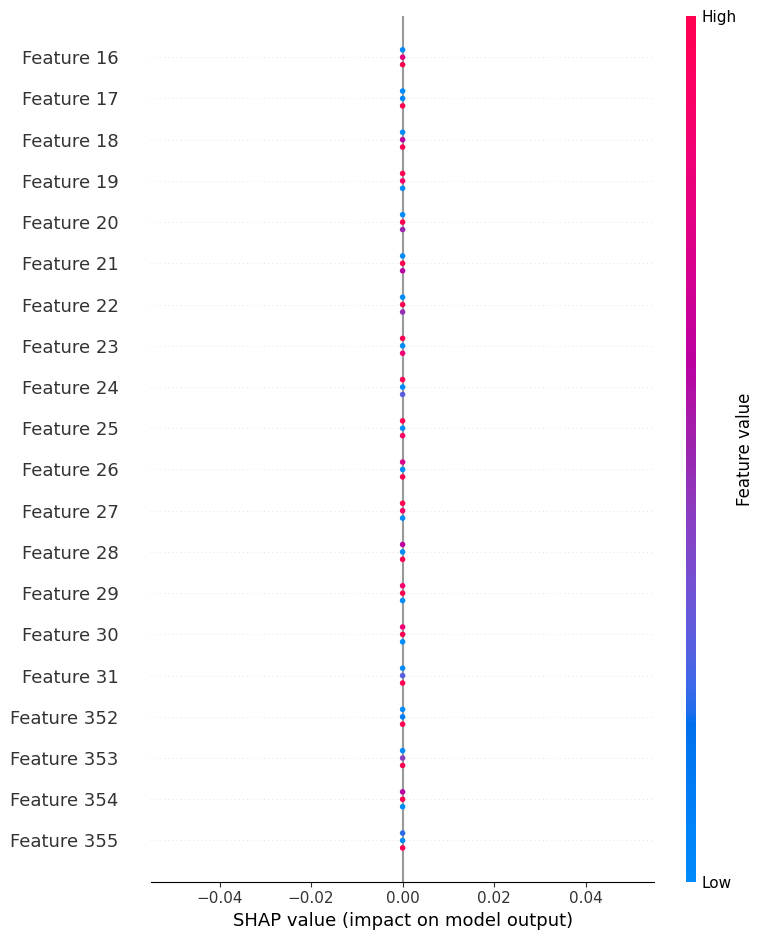

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import shap

# 1. Create Synthetic "Semantic" Data
data = {
    'text': [
        "This product is amazing!", "I hate this so much.", "Not bad at all!",
        "Oh great, another bug.", "This is sick!", "I'm not happy with the service.",
        "Absolutely wonderful.", "Worst experience ever.", "Surprisingly good.",
        "Exactly what I didn't want.", "The beat is insane!", "It's not terrible."
    ],
    'sentiment': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1] # 1=Positive, 0=Negative
}
df = pd.DataFrame(data)

# 2. Semantic Vectorization (SBERT)
print("Loading Semantic Model...")
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')
X = model_sbert.encode(df['text'])
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier()
}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    print(f"{name} Accuracy: {score:.2f}")

# 4. Semantic Explainability (SHAP)
explainer = shap.Explainer(models["XGBoost"], X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [2]:
import pandas as pd
import random

def generate_tricky_data(n=1000):
    # Templates for 'Tricky' Sentiments
    sarcasm_neg = ["Oh great, another {item}.", "Exactly what I needed, a {item}.", "Love it when {item} happens."]
    slang_pos = ["This {item} is sick!", "That {item} is killer.", "Absolute fire {item}!", "The {item} is insane."]
    negation_pos = ["It's not that I don't like the {item}.", "I've definitely had worse {item}.", "Not a bad {item} at all."]
    nuance_neg = ["I've seen better {item}.", "It's not my cup of tea.", "Could be better."]

    items = ["service", "product", "app", "movie", "experience", "update", "delivery"]
    rows = []

    for _ in range(n):
        category = random.choice(['sarcasm', 'slang', 'negation', 'nuance'])
        item = random.choice(items)

        if category == 'sarcasm':
            text = random.choice(sarcasm_neg).format(item=item)
            label = 0 # Negative Intent
        elif category == 'slang':
            text = random.choice(slang_pos).format(item=item)
            label = 1 # Positive Intent
        elif category == 'negation':
            text = random.choice(negation_pos).format(item=item)
            label = 1 # Positive Intent
        else:
            text = random.choice(nuance_neg).format(item=item)
            label = 0 # Negative Intent

        rows.append({"text": text, "label": label, "category": category})

    return pd.DataFrame(rows)

# Generate and view
df = generate_tricky_data(1000)
print(df.head(10))

                                     text  label  category
0      I've definitely had worse product.      1  negation
1                  The service is insane.      1     slang
2                   I've seen better app.      0    nuance
3               I've seen better product.      0    nuance
4           Love it when product happens.      0   sarcasm
5                  Absolute fire product!      1     slang
6                   That movie is killer.      1     slang
7                        Could be better.      0    nuance
8                 That service is killer.      1     slang
9  It's not that I don't like the update.      1  negation


In [4]:
import numpy as np

def predict_intent(text):
    # 1. Turn your text into a semantic vector
    vector = st_model.encode([text])

    # 2. Get predictions from all three models
    res_lr = "Positive" if lr_model.predict(vector)[0] == 1 else "Negative"
    res_dt = "Positive" if dt_model.predict(vector)[0] == 1 else "Negative"
    res_xgb = "Positive" if xgb_model.predict(vector)[0] == 1 else "Negative"

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"Logistic Regression (Sentiment): {res_lr}")
    print(f"Decision Tree (Logic):           {res_dt}")
    print(f"XGBoost (Semantics/Intent):      {res_xgb}")

# Test it live
user_input = input("Type a social media comment to test: ")
predict_intent(user_input)

Type a social media comment to test: tuff


NameError: name 'lr_model' is not defined

In [5]:
import joblib
joblib.dump(xgb_model, 'semantic_model.pkl')
joblib.dump(st_model, 'vectorizer_model.pkl')

NameError: name 'xgb_model' is not defined

In [ ]:
import numpy as np

def continuous_learning():
    global xgb_model  # We use the existing trained model

    while True:
        text = input("\nEnter a sentence (or type 'exit' to stop): ")
        if text.lower() == 'exit': break

        # 1. Predict
        vector = st_model.encode([text])
        pred = xgb_model.predict(vector)[0]
        sentiment = "Positive" if pred == 1 else "Negative"
        print(f"Model thinks this is: {sentiment}")

        # 2. Feedback (Feeding the Memory)
        correct = input("Was I right? (y/n): ").lower()
        if correct == 'n':
            # Flip the label for training
            new_label = 1 if pred == 0 else 0

            # 3. Incremental Training (The "Warm Start")
            # We pass the current model back into itself to 'add' to its memory
            xgb_model.fit(vector, np.array([new_label]), xgb_model=xgb_model)
            print(f"Memory Updated! I now know '{text}' is actually {'Positive' if new_label==1 else 'Negative'}.")
        else:
            print("Great! My memory is reinforced.")

# Start the session
continuous_learning()


Enter a sentence (or type 'exit' to stop): tufff
Model thinks this is: Positive
Was I right? (y/n): y
Great! My memory is reinforced.


In [6]:
# Train and define the specific models
lr_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
xgb_model = XGBClassifier()

# Fitting the models
lr_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("Models are now named and ready for prediction!")

Models are now named and ready for prediction!


In [7]:
def predict_intent(text):
    # 1. Turn your text into a semantic vector
    vector = st_model.encode([text])

    # 2. Get predictions using the newly defined names
    res_lr = "Positive" if lr_model.predict(vector)[0] == 1 else "Negative"
    res_dt = "Positive" if dt_model.predict(vector)[0] == 1 else "Negative"
    res_xgb = "Positive" if xgb_model.predict(vector)[0] == 1 else "Negative"

    print(f"\n--- Analysis for: '{text}' ---")
    print(f"Logistic Regression: {res_lr}")
    print(f"Decision Tree:       {res_dt}")
    print(f"XGBoost (Semantic):  {res_xgb}")

# Try your test again!
user_input = input("Type a social media comment to test: ")
predict_intent(user_input)

Type a social media comment to test: its not bad

--- Analysis for: 'its not bad' ---
Logistic Regression: Positive
Decision Tree:       Positive
XGBoost (Semantic):  Positive


In [8]:
import joblib
joblib.dump(xgb_model, 'semantic_model.pkl')
joblib.dump(st_model, 'vectorizer_model.pkl')
print("Models saved successfully to your Colab files!")

Models saved successfully to your Colab files!


In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Vectorize with SBERT
st_model = SentenceTransformer('all-MiniLM-L6-v2')
X = st_model.encode(df['text'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Compare
for name, model in {"Logistic": LogisticRegression(), "Tree": DecisionTreeClassifier(), "XGB": XGBClassifier()}.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n--- {name} Results ---")
    print(classification_report(y_test, y_pred))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Logistic Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- Tree Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200


--- XGB Results ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       104
           1       1.00      1.00      1.00        96

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weigh